In [1]:
import pandas as pd
import time


In [ ]:
import sys
import os


# Get the path to the project root
# '..' means go up one level from 'notebooks' to 'Project_Root'
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))

#Add the 'src' folder to Python's path
#This tells Python: "Look inside Project_Root/src for modules"
src_path = os.path.join(project_root, 'src')

if src_path not in sys.path:
    sys.path.append(src_path)
    
#Now you can import normally!
#Since we added 'src' to the path, we can import directly from the file name
try:
    from backend.src.graph import graph_create
    workflow=graph_create()
    print("✅ Successfully imported Graph Object")
except ImportError as e:
    print(f"❌ Import failed: {e}")
    print(f"Checked path: {src_path}")

✅ LLM ready!
✅ Successfully imported Graph Object


d:\Aayush\College\Interships\Infosys-Building an Ambient Agent\langgraph-email-assistant\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


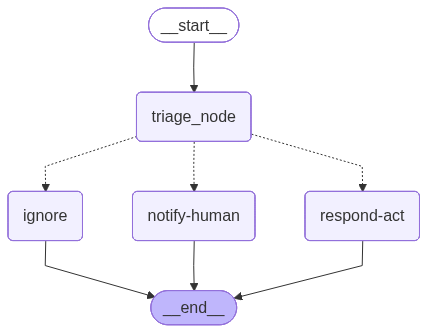

In [3]:
graph_create()

In [4]:
df=pd.read_csv("../data/test_emails.csv")
print(f"Loaded {len(df)} test emails")


Loaded 50 test emails


In [5]:
df.isnull().sum()

id                0
subject           0
body              0
label             0
ideal_response    0
dtype: int64

In [6]:
df.columns

Index(['id', 'subject', 'body', 'label', 'ideal_response'], dtype='object')

In [7]:
df['label']

0      respond-act
1           ignore
2     notify-human
3           ignore
4     notify-human
5      respond-act
6           ignore
7      respond-act
8     notify-human
9           ignore
10     respond-act
11    notify-human
12          ignore
13     respond-act
14    notify-human
15     respond-act
16          ignore
17    notify-human
18     respond-act
19          ignore
20    notify-human
21     respond-act
22          ignore
23    notify-human
24     respond-act
25          ignore
26    notify-human
27     respond-act
28          ignore
29    notify-human
30     respond-act
31          ignore
32    notify-human
33     respond-act
34          ignore
35    notify-human
36     respond-act
37          ignore
38    notify-human
39     respond-act
40          ignore
41    notify-human
42     respond-act
43          ignore
44    notify-human
45     respond-act
46          ignore
47    notify-human
48     respond-act
49          ignore
Name: label, dtype: object

In [8]:
results=[]

for itr,row in df.iterrows():
    email_input=f"""
    subject:{row['subject']}
    body:{row['body']}
    """

    print(email_input)

    response=workflow.invoke({"message":[],"mail":{"subject":row['subject'],"body":row["body"]}})

    predicted_label=response["triage_category"]
    results.append({
        "id":row['id'],
        "true_label":row['label'],
        'predicted_label': predicted_label,
        'subject': row['subject'],
        'correct': row['label'] == predicted_label

    })

    print(f"Email {row['id']}: True={row['label']} → Pred={predicted_label} ✅" if row['label'] == predicted_label else f"❌")
    time.sleep(2)



    subject:Meeting tomorrow?
    body:Hi, can we meet at 3pm tomorrow? Thanks!
    
✅ Triage: respond-act
Initiating React_Agent_Loop
Email 1: True=respond-act → Pred=respond-act ✅

    subject:Weekly Python Newsletter
    body:New Python 3.13 features released this week. Check out the changelog.
    
✅ Triage: ignore
Ignored email (newsletter/promo).
Email 2: True=ignore → Pred=ignore ✅

    subject:Urgent: Production server down
    body:ALERT: Prod server crashed at 14:30. Immediate action needed!
    
✅ Triage: notify-human
Notifying human: important email.
Email 3: True=notify-human → Pred=notify-human ✅

    subject:Udemy Course Sale: 80% Off
    body:Get Machine Learning courses for $9.99 only today! Limited time offer.
    
✅ Triage: ignore
Ignored email (newsletter/promo).
Email 4: True=ignore → Pred=ignore ✅

    subject:CEO: All-hands meeting rescheduled
    body:Emergency all-hands at 4 PM today. All team members required.
    
✅ Triage: notify-human
Notifying human: impo

In [10]:
results_df = pd.DataFrame(results)
accuracy = results_df['correct'].mean()
print(f"\n🎯 TRAGE ACCURACY: {accuracy:.1%} ({accuracy*len(df):.0f}/{len(df)})")
print("\nConfusion Matrix:")
print(pd.crosstab(results_df['true_label'], results_df['predicted_label']))

# Per-category accuracy
print("\nPer-category accuracy:")
print(results_df.groupby('true_label')['correct'].mean())



🎯 TRAGE ACCURACY: 82.0% (41/50)

Confusion Matrix:
predicted_label  ignore  notify-human  respond-act
true_label                                        
ignore               15             0            2
notify-human          0             9            7
respond-act           0             0           17

Per-category accuracy:
true_label
ignore          0.882353
notify-human    0.562500
respond-act     1.000000
Name: correct, dtype: float64
